# Campus Placement — ML Project
# Processing 

This notebook covers all steps between raw data and a model-ready feature matrix:
dropping leaky columns, encoding categoricals, scaling numeric features, and producing
a stratified train/test split.

All transformers are fit only on training data and applied to test data as fitting on the full
dataset would leak information about the test set into the model.

---
## 1. Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

SEED = 42
np.random.seed(SEED)

df = pd.read_csv('../data/Placement_Data_Full_Class.csv')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(3)

Loaded: 215 rows x 15 columns


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0


---
## 2. Drop columns that must not enter the model

Two columns are dropped before anything else:

- **`salary`** — only populated for placed students. Including it would be
  *target leakage*: the model would learn that salary > 0 means Placed, which
  is circular and useless on unseen data where salary is unknown.
- **`sl_no`** — a row index with no predictive meaning. Including arbitrary
  IDs can cause a model to memorise row numbers rather than learn patterns.

In [2]:
DROP_COLS = ['sl_no', 'salary']

df_clean = df.drop(columns=DROP_COLS)

print(f'Columns after dropping leaky features: {df_clean.shape[1]}')
print(df_clean.columns.tolist())

Columns after dropping leaky features: 13
['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status']


---
## 3. Separate features and target

In [3]:
TARGET = 'status'

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f'Features (X): {X.shape}  —  {X.columns.tolist()}')
print(f'Target  (y): {y.shape}  —  classes: {y.unique().tolist()}')

Features (X): (215, 12)  —  ['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p']
Target  (y): (215,)  —  classes: ['Placed', 'Not Placed']


---
## 4. Encode the target variable

sklearn classifiers require a numeric target so I encoded:
- `Not Placed` → 0
- `Placed`     → 1

This was done before the train/test split so the encoding is consistent across both sets.

In [4]:
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Confirm mapping
for cls, code in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    print(f'  {cls!r:15} → {code}')

print(f'\ny_encoded value counts: {pd.Series(y_encoded).value_counts().to_dict()}')

  'Not Placed'    → 0
  'Placed'        → 1

y_encoded value counts: {1: 148, 0: 67}


---
## 5. Identify feature types

In [5]:
numeric_features     = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f'Numeric features     ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features     (5): ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
Categorical features (7): ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']


---
## 6. Train / test split

Data was split before fitting any encoders or scalers to prevent data leaks between the sets as the scaler accessing the test set's distribution would lead to a more optimistic model than otherwise.

- The **80/20 split** is standard for a dataset of this size (172 train, 43 test)
- **`stratify=y_encoded`** preserves the 69/31 class ratio in both sets which matters given the afformentioned 2.2:1 imbalance

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train class balance: {pd.Series(y_train).value_counts(normalize=True).mul(100).round(1).to_dict()}')
print(f'Test  class balance: {pd.Series(y_test).value_counts(normalize=True).mul(100).round(1).to_dict()}')

Train: 172 rows  |  Test: 43 rows
Train class balance: {1: 68.6, 0: 31.4}
Test  class balance: {1: 69.8, 0: 30.2}


---
## 7. Encode categorical features

The **`LabelEncoder`** was used for each categorical column. All the categorical features are binary (2 unique values each).

Here, the encoder was fit on `X_train` only, then applied to both sets.

In [7]:
# Working on copies to preserve originals for inspection
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

label_encoders = {}  # stores the encoders for inspection or inverse-transform later !

for col in categorical_features:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])   # fit on train only
    X_test_enc[col]  = le.transform(X_test[col])         # apply to test
    label_encoders[col] = le
    print(f'{col:20} classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

gender               classes: {'F': np.int64(0), 'M': np.int64(1)}
ssc_b                classes: {'Central': np.int64(0), 'Others': np.int64(1)}
hsc_b                classes: {'Central': np.int64(0), 'Others': np.int64(1)}
hsc_s                classes: {'Arts': np.int64(0), 'Commerce': np.int64(1), 'Science': np.int64(2)}
degree_t             classes: {'Comm&Mgmt': np.int64(0), 'Others': np.int64(1), 'Sci&Tech': np.int64(2)}
workex               classes: {'No': np.int64(0), 'Yes': np.int64(1)}
specialisation       classes: {'Mkt&Fin': np.int64(0), 'Mkt&HR': np.int64(1)}


---
## 8. Scale numeric features

**`StandardScaler`** (zero mean, unit variance) was applied to all numeric features as this model is sensitive to feature magnitude like Logistic Regression and SVM. 

Tree-based models (Random Forest, Gradient Boosting) are scale-invariant, but scaling does no harm and keeps the preprocessing consistent regardless of which model we use.

This was again fit on the `X_train` group only.

In [8]:
scaler = StandardScaler()

X_train_enc[numeric_features] = scaler.fit_transform(X_train_enc[numeric_features])
X_test_enc[numeric_features]  = scaler.transform(X_test_enc[numeric_features])

print('Scaling complete.')
print(f'Train numeric means (should be ~0): {X_train_enc[numeric_features].mean().round(3).to_dict()}')
print(f'Train numeric stds  (should be ~1): {X_train_enc[numeric_features].std().round(3).to_dict()}')

Scaling complete.
Train numeric means (should be ~0): {'ssc_p': -0.0, 'hsc_p': -0.0, 'degree_p': 0.0, 'etest_p': -0.0, 'mba_p': 0.0}
Train numeric stds  (should be ~1): {'ssc_p': 1.003, 'hsc_p': 1.003, 'degree_p': 1.003, 'etest_p': 1.003, 'mba_p': 1.003}


---
## 9. Final check — preprocessed feature matrix

In [9]:
print('=== X_train_enc ===')
print(f'Shape: {X_train_enc.shape}')
print(f'Dtypes:\n{X_train_enc.dtypes}')
print(f'\nAny nulls: {X_train_enc.isnull().any().any()}')
print(f'\nFirst 3 rows:')
X_train_enc.head(3)

=== X_train_enc ===
Shape: (172, 12)
Dtypes:
gender              int64
ssc_p             float64
ssc_b               int64
hsc_p             float64
hsc_b               int64
hsc_s               int64
degree_p          float64
degree_t            int64
workex              int64
etest_p           float64
specialisation      int64
mba_p             float64
dtype: object

Any nulls: False

First 3 rows:


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p
147,1,0.260729,0,0.694120,0,1,-0.166768,0,0,0.778647,0,0.000789
161,1,-1.065759,1,-1.405431,1,1,-1.192126,0,0,-1.123471,1,0.074478
169,1,-0.664128,1,-2.212388,1,2,-0.678080,2,0,-1.359642,1,0.536711


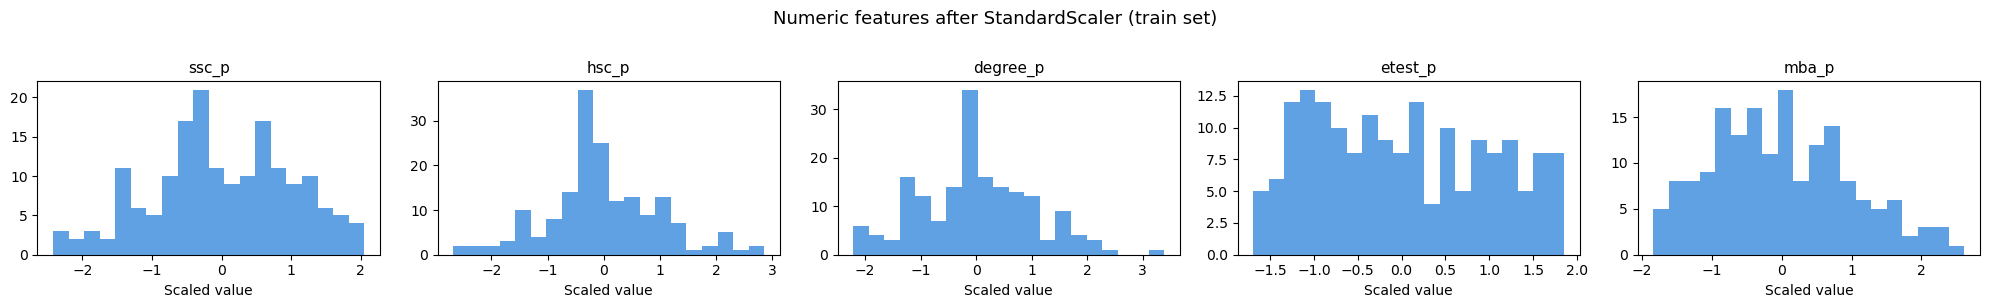

In [10]:
# Visualisations
fig, axes = plt.subplots(1, len(numeric_features), figsize=(4 * len(numeric_features), 3))
for i, col in enumerate(numeric_features):
    axes[i].hist(X_train_enc[col], bins=20, color='#378ADD', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Scaled value')
fig.suptitle('Numeric features after StandardScaler (train set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Data save
import joblib, os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models',         exist_ok=True)

# Save splits
X_train_enc.to_csv('../data/processed/X_train.csv', index=False)
X_test_enc.to_csv('../data/processed/X_test.csv',   index=False)
pd.Series(y_train, name='status').to_csv('../data/processed/y_train.csv', index=False)
pd.Series(y_test,  name='status').to_csv('../data/processed/y_test.csv',  index=False)

# Save transformers
joblib.dump(scaler,          '../models/scaler.pkl')
joblib.dump(label_encoders,  '../models/label_encoders.pkl')
joblib.dump(le_target,       '../models/target_encoder.pkl')

print('Saved:')
print('  data/processed/X_train.csv  X_test.csv  y_train.csv  y_test.csv')
print('  models/scaler.pkl  label_encoders.pkl  target_encoder.pkl')

Saved:
  data/processed/X_train.csv  X_test.csv  y_train.csv  y_test.csv
  models/scaler.pkl  label_encoders.pkl  target_encoder.pkl
